In [1]:
pip install pandas matplotlib seaborn scikit-learn openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------------------- -------- 6.6/8.2 MB 31.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 27.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------------------------------- ---- 7.3/8.2 MB 34.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 19.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 22.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------------------------------------- -- 6.6/7.1 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 27.1 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------- -------------------------------- 7.1/3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: C:\Users\Swagata\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
# CELL 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

In [10]:
# CELL 2 — Load Dataset
df = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv", encoding="ISO-8859-1")

print(f"Shape: {df.shape}")
print(df.head())

C:\Users\Swagata\AppData\Local\Temp\ipykernel_5384\3301572338.py:2: DtypeWarning: Columns (0: status, 1: created_at, 2: sku, 3: increment_id, 4: category_name_1, 5: sales_commission_code, 6: payment_method, 7: Working Date, 8: BI Status, 9:  MV , 10: Customer Since, 11: M-Y, 12: FY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv", encoding="ISO-8859-1")


Shape: (1048575, 26)
    item_id          status created_at  \
0  211131.0        complete   7/1/2016   
1  211133.0        canceled   7/1/2016   
2  211134.0        canceled   7/1/2016   
3  211135.0        complete   7/1/2016   
4  211136.0  order_refunded   7/1/2016   

                                                 sku   price  qty_ordered  \
0                                  kreations_YI 06-L  1950.0          1.0   
1  kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...   240.0          1.0   
2                                 Ego_UP0017-999-MR0  2450.0          1.0   
3                                     kcc_krone deal   360.0          1.0   
4                                        BK7010400AG   555.0          2.0   

   grand_total increment_id    category_name_1 sales_commission_code  ...  \
0       1950.0    100147443    Women's Fashion                    \N  ...   
1        240.0    100147444  Beauty & Grooming                    \N  ...   
2       2450.0    100147445    W

In [11]:
# CELL 3 — Basic Info
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  str    
 2   created_at             584524 non-null  str    
 3   sku                    584504 non-null  str    
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  str    
 9   sales_commission_code  447346 non-null  str    
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  str    
 12  Working Date           584524 non-null  str    
 13  BI Status              584524 non-null  str    
 14   MV                    584524 non-null  str  

In [12]:
# Drop fully empty unnamed columns
df = df.drop(columns=["Unnamed: 21", "Unnamed: 22", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25"])

# Drop rows where Customer ID is missing (these are the empty rows)
df = df.dropna(subset=["Customer ID", "grand_total", "created_at"])

# Keep only completed orders (remove canceled/refunded)
df = df[df["status"] == "complete"]

# Reset index
df = df.reset_index(drop=True)

print(f"Clean dataset shape: {df.shape}")
print(df["status"].value_counts())

Clean dataset shape: (233685, 21)
status
complete    233685
Name: count, dtype: int64


In [13]:
# Convert created_at to datetime
df["created_at"] = pd.to_datetime(df["created_at"])

# Set reference date (day after last transaction)
reference_date = df["created_at"].max() + pd.Timedelta(days=1)

print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")
print(f"Reference date: {reference_date}")

Date range: 2016-07-01 00:00:00 to 2018-08-12 00:00:00
Reference date: 2018-08-13 00:00:00


In [14]:
# Build RFM Table
rfm = df.groupby("Customer ID").agg(
    Recency   = ("created_at", lambda x: (reference_date - x.max()).days),
    Frequency = ("increment_id", "nunique"),
    Monetary  = ("grand_total", "sum")
).reset_index()

print(f"Total Unique Customers: {len(rfm)}")
print(rfm.head(10))
print("\nRFM Summary:")
print(rfm.describe())

Total Unique Customers: 67094
   Customer ID  Recency  Frequency    Monetary
0          1.0      773          1     1950.00
1          3.0      451          1     4980.00
2          4.0        1        230  1290445.10
3          6.0      773          1      170.00
4          7.0      485          4      105.00
5          9.0      773          1     5500.00
6         11.0      545          4     1095.00
7         12.0      632          3     3783.00
8         13.0      580         93   410495.80
9         15.0      216         12    83248.93

RFM Summary:
         Customer ID       Recency     Frequency      Monetary
count   67094.000000  67094.000000  67094.000000  6.709400e+04
mean    48029.885340    399.875741      2.526351  1.746469e+04
std     29615.452851    187.866861     14.392706  1.543632e+05
min         1.000000      1.000000      1.000000  0.000000e+00
25%     22173.250000    259.000000      1.000000  9.490000e+02
50%     45612.000000    382.000000      1.000000  2.640000e+0

In [15]:
# Score R, F, M on scale of 1-4
rfm["R_Score"] = pd.qcut(rfm["Recency"],   q=4, labels=[4,3,2,1])  # lower recency = better
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"],  q=4, labels=[1,2,3,4])

# Combined RFM Score
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

print(rfm[["Customer ID", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score"]].head(10))

   Customer ID  Recency  Frequency    Monetary R_Score F_Score M_Score  \
0          1.0      773          1     1950.00       1       1       2   
1          3.0      451          1     4980.00       2       1       3   
2          4.0        1        230  1290445.10       4       4       4   
3          6.0      773          1      170.00       1       1       1   
4          7.0      485          4      105.00       2       4       1   
5          9.0      773          1     5500.00       1       1       3   
6         11.0      545          4     1095.00       2       4       2   
7         12.0      632          3     3783.00       1       4       3   
8         13.0      580         93   410495.80       2       4       4   
9         15.0      216         12    83248.93       4       4       4   

  RFM_Score  
0       112  
1       213  
2       444  
3       111  
4       241  
5       113  
6       242  
7       143  
8       244  
9       444  


In [16]:
from sklearn.preprocessing import StandardScaler

# Use only R, F, M columns for clustering
rfm_cluster = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_cluster)

print("✅ Data scaled successfully!")
print(f"Shape: {rfm_scaled.shape}")

✅ Data scaled successfully!
Shape: (67094, 3)


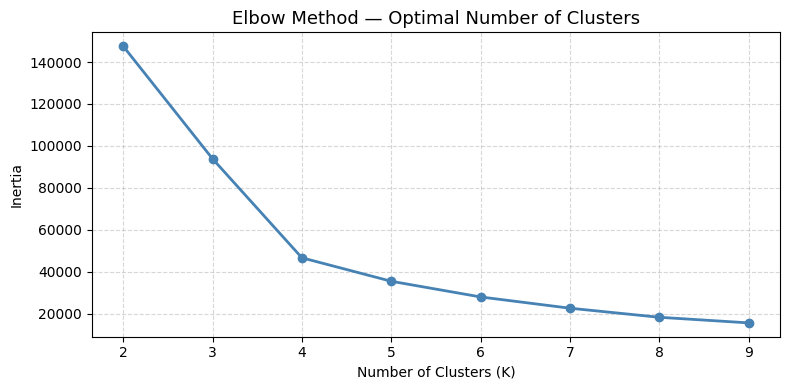

✅ Elbow curve saved!


In [17]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()
print("✅ Elbow curve saved!")

In [18]:
# Apply KMeans with 4 clusters
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = km.fit_predict(rfm_scaled)

# Cluster summary
cluster_summary = rfm.groupby("Cluster").agg(
    Total_Customers = ("Customer ID", "count"),
    Avg_Recency     = ("Recency", "mean"),
    Avg_Frequency   = ("Frequency", "mean"),
    Avg_Monetary    = ("Monetary", "mean")
).round(2)

print(cluster_summary)

         Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                           
0                  31081       580.17           1.74       7667.74
1                      1       430.00           1.00   35776000.00
2                     26       311.42         600.19    1504350.42
3                  35986       244.22           2.78      23858.33


In [20]:
# Remove extreme outliers
# Cap Frequency at 99th percentile and Monetary at 99th percentile
freq_cap = rfm["Frequency"].quantile(0.99)
mon_cap  = rfm["Monetary"].quantile(0.99)

rfm_clean = rfm[
    (rfm["Frequency"] <= freq_cap) & 
    (rfm["Monetary"]  <= mon_cap)
].copy()

print(f"Original customers : {len(rfm)}")
print(f"After removing outliers: {len(rfm_clean)}")
print(f"Removed: {len(rfm) - len(rfm_clean)} outliers")

Original customers : 67094
After removing outliers: 66014
Removed: 1080 outliers


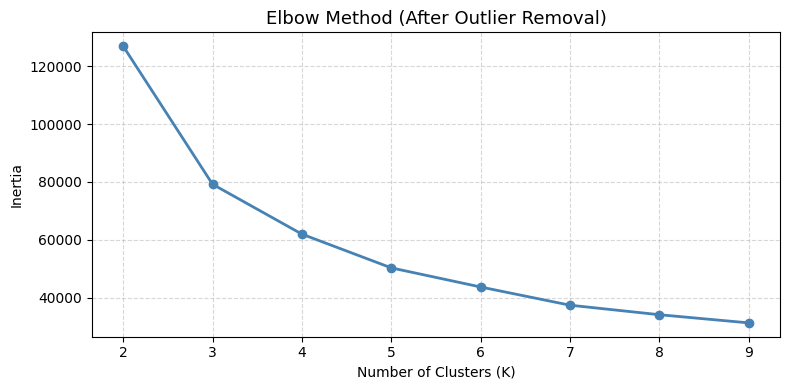

         Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                           
0                  29861       249.25           1.41       7625.11
1                   4745       311.76           6.64      32399.78
2                   2017       245.03           5.77     124024.21
3                  29391       583.22           1.34       4998.86


In [21]:
# Re-scale
rfm_cluster2 = rfm_clean[["Recency", "Frequency", "Monetary"]].copy()
rfm_scaled2  = scaler.fit_transform(rfm_cluster2)

# New elbow check
inertia2 = []
for k in range(2, 10):
    km2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    km2.fit(rfm_scaled2)
    inertia2.append(km2.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), inertia2, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method (After Outlier Removal)", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 10))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("elbow_curve_clean.png", dpi=150)
plt.show()

# Apply K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_clean["Cluster"] = km_final.fit_predict(rfm_scaled2)

# New cluster summary
cluster_summary2 = rfm_clean.groupby("Cluster").agg(
    Total_Customers = ("Customer ID", "count"),
    Avg_Recency     = ("Recency", "mean"),
    Avg_Frequency   = ("Frequency", "mean"),
    Avg_Monetary    = ("Monetary", "mean")
).round(2)

print(cluster_summary2)

In [22]:
# Assign segment labels
cluster_labels = {
    0: "At Risk",
    1: "Loyal Customers",
    2: "Champions",
    3: "Dormant"
}

rfm_clean["Segment"] = rfm_clean["Cluster"].map(cluster_labels)
print(rfm_clean["Segment"].value_counts())

Segment
At Risk            29861
Dormant            29391
Loyal Customers     4745
Champions           2017
Name: count, dtype: int64


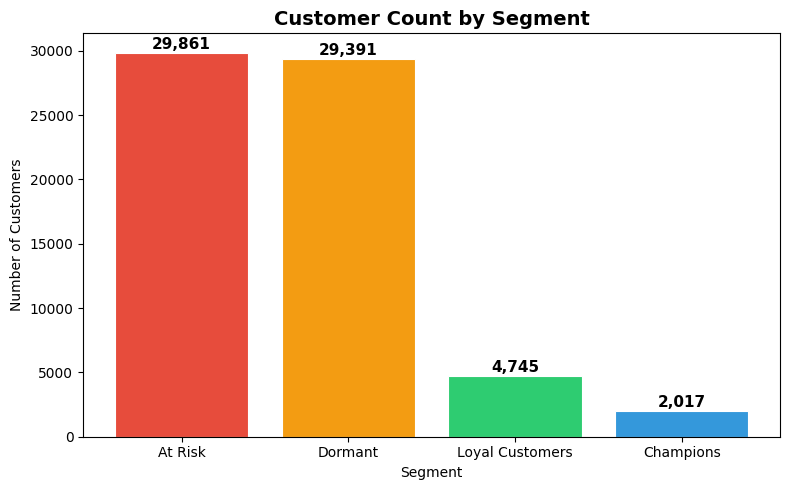

In [23]:
seg_counts = rfm_clean["Segment"].value_counts()

plt.figure(figsize=(8, 5))
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#3498db"]
bars = plt.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{val:,}", ha="center", fontsize=11, fontweight="bold")

plt.title("Customer Count by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("segment_count.png", dpi=150)
plt.show()

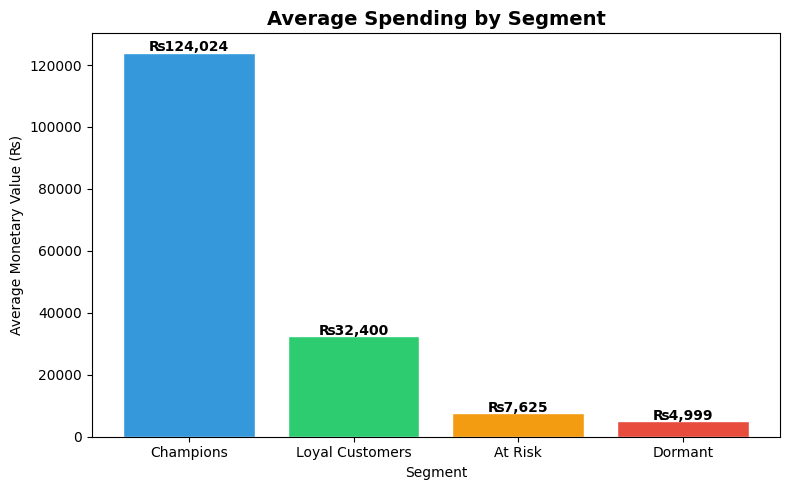

In [24]:
seg_monetary = rfm_clean.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors2 = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]
bars2 = plt.bar(seg_monetary.index, seg_monetary.values, color=colors2, edgecolor="white")

for bar, val in zip(bars2, seg_monetary.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"₨{val:,.0f}", ha="center", fontsize=10, fontweight="bold")

plt.title("Average Spending by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Average Monetary Value (₨)")
plt.tight_layout()
plt.savefig("segment_monetary.png", dpi=150)
plt.show()

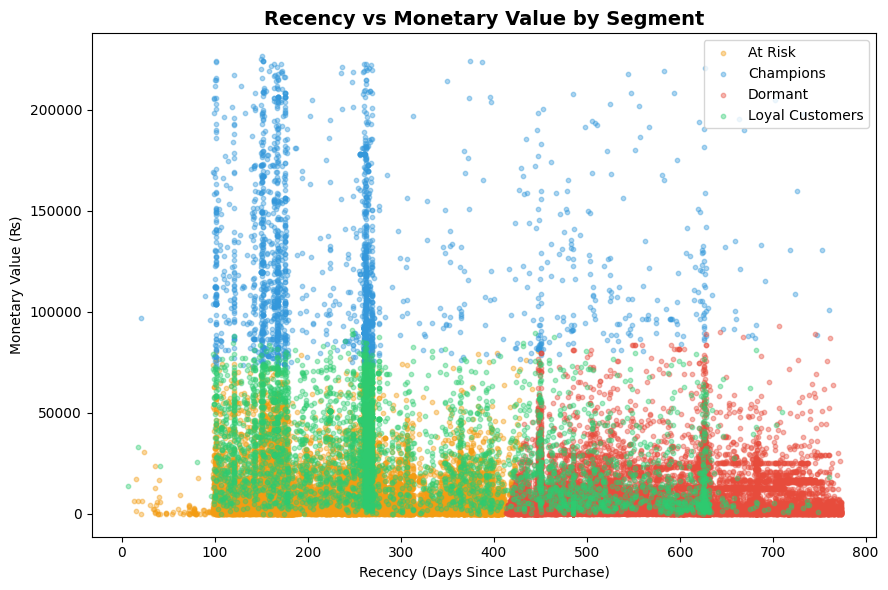

In [25]:
plt.figure(figsize=(9, 6))
colors_map = {"Champions": "#3498db", "Loyal Customers": "#2ecc71",
              "At Risk": "#f39c12", "Dormant": "#e74c3c"}

for seg, grp in rfm_clean.groupby("Segment"):
    plt.scatter(grp["Recency"], grp["Monetary"],
                label=seg, alpha=0.4, s=10, color=colors_map[seg])

plt.title("Recency vs Monetary Value by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary Value (₨)")
plt.legend()
plt.tight_layout()
plt.savefig("rfm_scatter.png", dpi=150)
plt.show()